# Chapter 2, Example 2: From a Factor Graph to a Normal Factor Graph

This notebook studies a small binary parity-check model in two equivalent graphical representations:

1. an ordinary factor graph, where variables are nodes;
2. a normal factor graph, where variables live on edges and equality factors enforce consistency among local copies.

The example is deliberately small enough for exact enumeration. It demonstrates that the conversion preserves the partition function and the physical marginals, while also revealing why equality factors are essential.

The construction will be reused later in the book when normal factor graphs become the natural language for gauge transformations, loop calculus, and tensor-network contraction.

## 1. Binary parity-check model

Let $x_i\in\{0,1\}$ for $i=1,2,3,4$. We impose two even-parity constraints,

$$
x_1\oplus x_2\oplus x_3=0,
$$

and

$$
x_2\oplus x_3\oplus x_4=0.
$$

Local evidence is represented by unary factors

$$
g_i(x_i)=\exp(h_i(2x_i-1)).
$$

The unnormalized weight is

$$
w_{\mathrm{FG}}(\boldsymbol{x})
=
\left(\prod_{i=1}^4 g_i(x_i)\right)
\psi_A(x_1,x_2,x_3)
\psi_B(x_2,x_3,x_4),
$$

where each parity factor equals one when its constraint is satisfied and zero otherwise. The hard factors remove invalid configurations exactly rather than merely penalizing them.

In [1]:
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Publication-oriented typography shared by all Chapter 2 figures.
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
    "lines.linewidth": 2.0,
})

CWD = Path.cwd()
if CWD.name == "ch02":
    NOTEBOOK_DIR = CWD
elif (CWD / "notebooks" / "ch02").exists():
    NOTEBOOK_DIR = CWD / "notebooks" / "ch02"
else:
    NOTEBOOK_DIR = CWD
FIG_DIR = NOTEBOOK_DIR / "figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)


H = np.array([0.55, -0.20, 0.35, -0.45])


def save_figure(fig, stem):
    for suffix, kwargs in [("pdf", {}), ("png", {"dpi": 220})]:
        path = FIG_DIR / f"{stem}.{suffix}"
        fig.savefig(path, bbox_inches="tight", **kwargs)
        print(f"Saved: {path}")


def unary_factor(i, x):
    return float(np.exp(H[i] * (2 * x - 1)))


def even_parity(*bits):
    return float(sum(bits) % 2 == 0)


def fg_weight(x):
    x1, x2, x3, x4 = x
    unary = np.prod([unary_factor(i, bit) for i, bit in enumerate(x)])
    return unary * even_parity(x1, x2, x3) * even_parity(x2, x3, x4)

## 2. The two graphical representations

In the ordinary factor graph, the variables $x_2$ and $x_3$ each participate in three factors: one unary factor and two parity factors.

A normal factor graph requires every variable to appear on an edge and therefore to be incident to exactly two factor nodes. We introduce local copies of $x_2$ and $x_3$ and add equality factors

$$
\delta_2(x_2^{g},x_2^{A},x_2^{B})
=
\mathbb{I}\{x_2^{g}=x_2^{A}=x_2^{B}\},
$$

and similarly for $x_3$. The superscripts identify the unary factor and the two parity factors touching each copy.

Saved: figs/ch02_02_fg_and_nfg.pdf


Saved: figs/ch02_02_fg_and_nfg.png


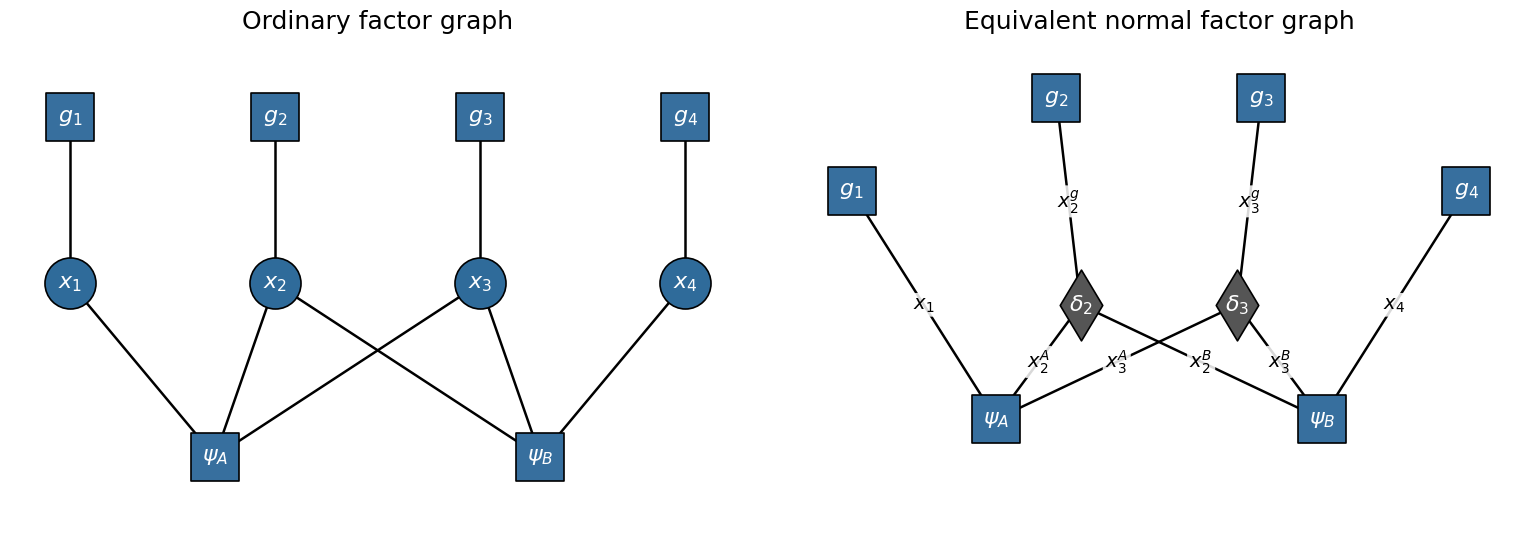

In [2]:
# Ordinary factor graph.
fg = nx.Graph()
variables = ["x1", "x2", "x3", "x4"]
factors = ["g1", "g2", "g3", "g4", "A", "B"]
fg.add_nodes_from(variables, kind="variable")
fg.add_nodes_from(factors, kind="factor")
fg.add_edges_from([
    ("g1", "x1"), ("g2", "x2"), ("g3", "x3"), ("g4", "x4"),
    ("A", "x1"), ("A", "x2"), ("A", "x3"),
    ("B", "x2"), ("B", "x3"), ("B", "x4"),
])
pos_fg = {
    "x1": (0, 0), "x2": (1.7, 0), "x3": (3.4, 0), "x4": (5.1, 0),
    "g1": (0, 1.2), "g2": (1.7, 1.2), "g3": (3.4, 1.2), "g4": (5.1, 1.2),
    "A": (1.2, -1.25), "B": (3.9, -1.25),
}
labels_fg = {**{f"x{i}": rf"$x_{i}$" for i in range(1, 5)},
             **{f"g{i}": rf"$g_{i}$" for i in range(1, 5)},
             "A": r"$\psi_A$", "B": r"$\psi_B$"}

# Normal factor graph: all displayed nodes are factors; edge labels are variables.
nfg = nx.Graph()
nfg_nodes = ["g1", "g2", "g3", "g4", "A", "B", "eq2", "eq3"]
nfg.add_nodes_from(nfg_nodes)
nfg_edges = [
    ("g1", "A", "x1"),
    ("g4", "B", "x4"),
    ("g2", "eq2", "x2g"), ("A", "eq2", "x2A"), ("B", "eq2", "x2B"),
    ("g3", "eq3", "x3g"), ("A", "eq3", "x3A"), ("B", "eq3", "x3B"),
]
for u, v, label in nfg_edges:
    nfg.add_edge(u, v, label=label)
pos_nfg = {
    "g1": (0, 0.8), "g2": (1.7, 1.45), "g3": (3.4, 1.45), "g4": (5.1, 0.8),
    "A": (1.2, -0.8), "B": (3.9, -0.8), "eq2": (1.9, 0), "eq3": (3.2, 0),
}
labels_nfg = {
    "g1": r"$g_1$", "g2": r"$g_2$", "g3": r"$g_3$", "g4": r"$g_4$",
    "A": r"$\psi_A$", "B": r"$\psi_B$", "eq2": r"$\delta_2$", "eq3": r"$\delta_3$",
}
edge_tex = {
    "x1": r"$x_1$", "x4": r"$x_4$",
    "x2g": r"$x_2^{g}$", "x2A": r"$x_2^{A}$", "x2B": r"$x_2^{B}$",
    "x3g": r"$x_3^{g}$", "x3A": r"$x_3^{A}$", "x3B": r"$x_3^{B}$",
}
edge_labels = {(u, v): edge_tex[d["label"]] for u, v, d in nfg.edges(data=True)}

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5))

variable_color = "#2F6B9A"
factor_color = "#376F9E"
equality_color = "#555555"

ax = axes[0]
nx.draw_networkx_edges(fg, pos_fg, ax=ax, width=1.8)
nx.draw_networkx_nodes(
    fg, pos_fg, nodelist=variables, node_shape="o", node_size=1350,
    node_color=variable_color, edgecolors="black", linewidths=1.2, ax=ax
)
nx.draw_networkx_nodes(
    fg, pos_fg, nodelist=factors, node_shape="s", node_size=1150,
    node_color=factor_color, edgecolors="black", linewidths=1.2, ax=ax
)
nx.draw_networkx_labels(fg, pos_fg, labels_fg, font_size=16, font_color="white", ax=ax)
ax.set_title("Ordinary factor graph", pad=9)
ax.set_xlim(-0.5, 5.6)
ax.set_ylim(-1.75, 1.75)
ax.axis("off")

ax = axes[1]
nx.draw_networkx_edges(nfg, pos_nfg, ax=ax, width=1.8)
nx.draw_networkx_nodes(
    nfg, pos_nfg, nodelist=["g1", "g2", "g3", "g4", "A", "B"],
    node_shape="s", node_size=1200, node_color=factor_color,
    edgecolors="black", linewidths=1.2, ax=ax
)
nx.draw_networkx_nodes(
    nfg, pos_nfg, nodelist=["eq2", "eq3"], node_shape="d", node_size=1300,
    node_color=equality_color, edgecolors="black", linewidths=1.2, ax=ax
)
nx.draw_networkx_labels(nfg, pos_nfg, labels_nfg, font_size=16, font_color="white", ax=ax)
nx.draw_networkx_edge_labels(
    nfg, pos_nfg, edge_labels=edge_labels, font_size=14, rotate=False,
    bbox={"boxstyle": "round,pad=0.12", "facecolor": "white", "edgecolor": "none", "alpha": 0.85},
    ax=ax
)
ax.set_title("Equivalent normal factor graph", pad=9)
ax.set_xlim(-0.5, 5.6)
ax.set_ylim(-1.55, 1.85)
ax.axis("off")

fig.tight_layout(pad=0.8, w_pad=2.2)
save_figure(fig, "ch02_02_fg_and_nfg")
plt.show()

## 3. Exact enumeration in the ordinary factor graph

There are $2^4=16$ assignments of the physical variables. Only assignments satisfying both parity checks have nonzero weight. Enumeration gives a transparent reference value for the partition function and the normalized probabilities.

In [3]:
physical_states = np.array(list(product([0, 1], repeat=4)), dtype=int)
fg_weights = np.array([fg_weight(x) for x in physical_states])
Z_fg = fg_weights.sum()
p_fg = fg_weights / Z_fg

rows = []
for x, w, p in zip(physical_states, fg_weights, p_fg):
    rows.append({
        "state": "".join(str(v) for v in x),
        "parity A": int(even_parity(x[0], x[1], x[2])),
        "parity B": int(even_parity(x[1], x[2], x[3])),
        "weight": w,
        "probability": p,
    })
fg_table = pd.DataFrame(rows)
print(f"Z_FG = {Z_fg:.10f}")
display(fg_table[fg_table["weight"] > 0].reset_index(drop=True))

assert np.isclose(p_fg.sum(), 1.0)

Z_FG = 4.3832408601


,state,parity A,parity B,weight,probability
0,0000,1,1,0.778801,0.177677
1,0110,1,1,1.051271,0.239839
2,1011,1,1,1.915541,0.437015
3,1101,1,1,0.637628,0.145470


Saved: figs/ch02_02_valid_codeword_probabilities.pdf


Saved: figs/ch02_02_valid_codeword_probabilities.png


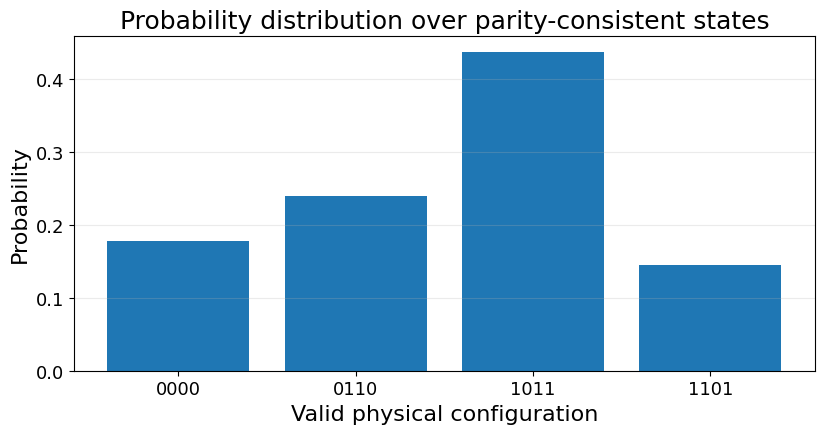

In [4]:
valid = fg_table[fg_table["weight"] > 0].copy()
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.bar(valid["state"], valid["probability"])
ax.set_xlabel("Valid physical configuration")
ax.set_ylabel("Probability")
ax.set_title("Probability distribution over parity-consistent states")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
save_figure(fig, "ch02_02_valid_codeword_probabilities")
plt.show()

## 4. Exact enumeration in the normal factor graph

The normal factor graph has eight edge variables,

$$
(x_1,x_4,x_2^{g},x_2^{A},x_2^{B},x_3^{g},x_3^{A},x_3^{B}).
$$

There are therefore $2^8=256$ raw edge assignments. The equality factors suppress every assignment in which the copies of a physical variable disagree.

The normal-factor-graph weight is

$$
w_{\mathrm{NFG}}
=
g_1(x_1)g_4(x_4)g_2(x_2^g)g_3(x_3^g)
\psi_A(x_1,x_2^A,x_3^A)
\psi_B(x_2^B,x_3^B,x_4)
\delta_2\delta_3.
$$

In [5]:
def equality_factor(*bits):
    return float(all(bit == bits[0] for bit in bits))


def nfg_weight(edge_state, include_equalities=True):
    x1, x4, x2g, x2A, x2B, x3g, x3A, x3B = edge_state
    weight = (
        unary_factor(0, x1)
        * unary_factor(3, x4)
        * unary_factor(1, x2g)
        * unary_factor(2, x3g)
        * even_parity(x1, x2A, x3A)
        * even_parity(x2B, x3B, x4)
    )
    if include_equalities:
        weight *= equality_factor(x2g, x2A, x2B)
        weight *= equality_factor(x3g, x3A, x3B)
    return weight


edge_states = np.array(list(product([0, 1], repeat=8)), dtype=int)
nfg_weights = np.array([nfg_weight(x) for x in edge_states])
Z_nfg = nfg_weights.sum()
p_nfg = nfg_weights / Z_nfg

print(f"Z_FG  = {Z_fg:.12f}")
print(f"Z_NFG = {Z_nfg:.12f}")
print(f"Number of nonzero NFG edge assignments = {(nfg_weights > 0).sum()}")

assert np.isclose(Z_fg, Z_nfg)

Z_FG  = 4.383240860083
Z_NFG = 4.383240860083
Number of nonzero NFG edge assignments = 4


## 5. Equality of physical marginals

The marginal of $x_2$ can be computed in the ordinary factor graph. In the normal factor graph, it can be computed from any one of the three edge copies. If equality factors are present, all three answers must agree.

In [6]:
def binary_marginal(states, probabilities, column):
    return np.array([
        probabilities[states[:, column] == value].sum()
        for value in [0, 1]
    ])

m_x2_fg = binary_marginal(physical_states, p_fg, 1)
m_x2_copies = {
    "x2g": binary_marginal(edge_states, p_nfg, 2),
    "x2A": binary_marginal(edge_states, p_nfg, 3),
    "x2B": binary_marginal(edge_states, p_nfg, 4),
}

comparison = pd.DataFrame({"FG x2": m_x2_fg, **m_x2_copies}, index=["0", "1"])
display(comparison)

for marginal in m_x2_copies.values():
    assert np.allclose(m_x2_fg, marginal)

,FG x2,x2g,x2A,x2B
0,0.614692,0.614692,0.614692,0.614692
1,0.385308,0.385308,0.385308,0.385308


## 6. What fails if an equality factor is omitted?

The equality factors are not decorative. Without them, the local copies cease to represent one physical variable. The resulting network has a different partition function and different edge marginals.

,model,partition function,P(x2=1) or P(x2g=1)
0,ordinary FG,4.383241,0.385308
1,correct NFG,4.383241,0.385308
2,NFG without equality factors,88.321614,0.401312


Saved: figs/ch02_02_equality_factor_diagnostic.pdf


Saved: figs/ch02_02_equality_factor_diagnostic.png


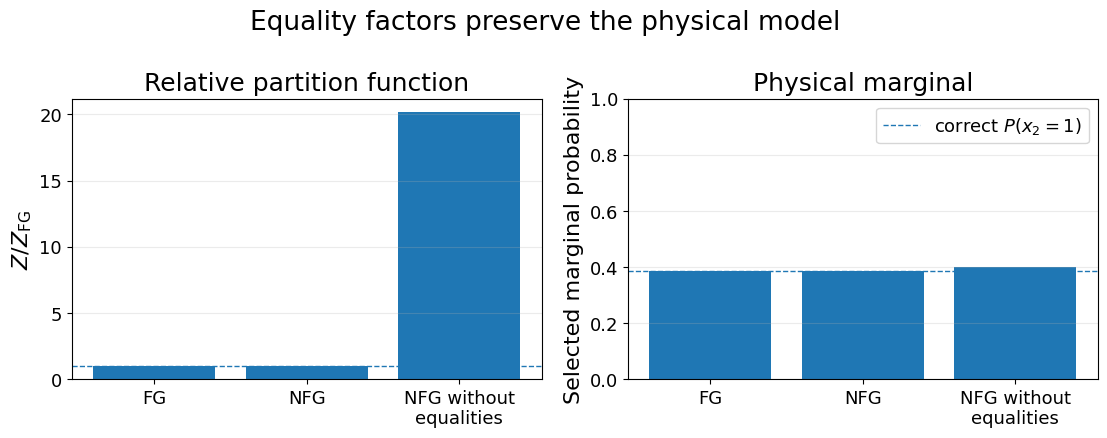

In [7]:
nfg_weights_no_eq = np.array([nfg_weight(x, include_equalities=False) for x in edge_states])
Z_no_eq = nfg_weights_no_eq.sum()
p_no_eq = nfg_weights_no_eq / Z_no_eq
m_no_eq = binary_marginal(edge_states, p_no_eq, 2)

summary = pd.DataFrame({
    "model": ["ordinary FG", "correct NFG", "NFG without equality factors"],
    "partition function": [Z_fg, Z_nfg, Z_no_eq],
    "P(x2=1) or P(x2g=1)": [m_x2_fg[1], m_x2_copies["x2g"][1], m_no_eq[1]],
})
display(summary)

short_labels = ["FG", "NFG", "NFG without\nequalities"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))
axes[0].bar(short_labels, summary["partition function"] / Z_fg)
axes[0].axhline(1.0, linewidth=1, linestyle="--")
axes[0].set_ylabel(r"$Z/Z_{\mathrm{FG}}$")
axes[0].set_title("Relative partition function")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(short_labels, summary["P(x2=1) or P(x2g=1)"])
axes[1].axhline(m_x2_fg[1], linewidth=1, linestyle="--", label=r"correct $P(x_2=1)$")
axes[1].set_ylabel("Selected marginal probability")
axes[1].set_title("Physical marginal")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

fig.suptitle("Equality factors preserve the physical model")
fig.tight_layout()
save_figure(fig, "ch02_02_equality_factor_diagnostic")
plt.show()

## 7. Interpretation

This example separates three ideas that are often conflated:

- normalization of a probability distribution by dividing by $Z$;
- conversion of a factor graph into a normal factor graph;
- equality constraints that identify several local edge variables with one physical variable.

The normal factor graph has more local variables but exactly the same physical content. Its advantage is structural: every variable is an edge, so local transformations can be applied edge by edge. This form will later support gauge transformations, loop expansions, and tensor-network language.

## 8. Exercises

### Exercise 1: Change the evidence

Replace the vector $H$ by a new set of local fields. Recompute the valid-state probabilities and verify again that the two partition functions agree.

### Exercise 2: Odd parity

Change one parity factor from even parity to odd parity. Determine the valid configurations and explain how the probability distribution changes.

### Exercise 3: Remove one equality factor

Keep $\delta_2$ but remove $\delta_3$. Compute the three marginals associated with the copies of $x_3$ and identify which ones disagree.

### Exercise 4: Add a third parity check

Add $\psi_C(x_1,x_3,x_4)$. Draw the ordinary factor graph and its normal-factor-graph conversion. Count the edge variables and equality factors before writing code.

### Exercise 5: Replace binary variables by ternary variables

Let $x_i\in\{0,1,2\}$ and replace parity by a modulo-three constraint. Adapt the enumeration and verify the partition-function identity.

### Exercise 6: Tensor interpretation

Represent each factor as a multidimensional array. Express the normal-factor-graph partition function as a tensor contraction and identify the equality tensor explicitly.